# $\Psi(2S)$ discovery with CMS data
#### Gabriele Radano, Matteo Bellino - Spring semester 2025

# 0. Importing packages

In [3]:
# Importing packages
import pickle as pkl                 # Needed to import the pkl files
import numpy  as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from dataclasses import dataclass
from scipy.integrate import quad     # Numerical integral evaluation, useful to compute the integral of the model inside the bin
import sys                           # Needed to know what's the highest float value accepted

# 1. Loading data

In [5]:
# Importing data from files
with open('DataSet.pkl', 'rb') as file: # The 'rb' stands for 'read binary', necessary for this kind of file
    data_HS = pkl.load(file)            # Data with High Statistics 
    
with open('DataSet_lowstat.pkl', 'rb') as file:
    data_LS = pkl.load(file)            # Data with Low Statistics

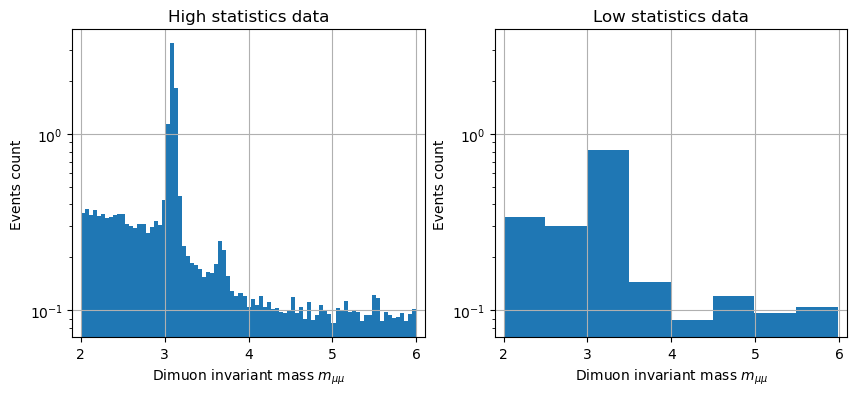

In [6]:
# Plotting raw data
normalize = True
scale     = 'log'
bin_num   = int(np.sqrt(len(data_HS))/2)

fig, axes = plt.subplots(1,2, figsize=(10,4))

ax = axes[0]
ax.grid(1)
ax.hist(data_HS, density=normalize, bins=bin_num)
ax.set_title('High statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_yscale(scale)
ylim = ax.set_ylim()

ax = axes[1]
ax.grid(1)
ax.hist(data_LS, density=normalize, bins=int(bin_num/10))
ax.set_title('Low statistics data')
ax.set_xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
ax.set_ylabel('Events count')
ax.set_xlim((1.9,6.1))
ax.set_ylim(ylim)
ax.set_yscale(scale)
plt.show()

# 2. Defining the model

## 2.1. Bare background

Following the instructions of the README file, we will model the bare background (and with that I mean without the
peak of the J/$\Psi$ resonance) with Chebychev polynomial of order three. 
Being honest, they are not super clear about what this is so I had to dig inside the CERN definitions of tools they use to fit.
[There](https://root.cern/doc/master/ChebyshevPol_8h_source.html), at line 66, we see how the third order Chebyshev polynomial is evaluated.
Apparently, it returns
\begin{equation}
    c_3 \cdot (4x^3-3x) + c_2\cdot(2x^2 - 1) + c_1\cdot x + c_0
\end{equation}
but this has four parameters! However we shall factor in also the normalization condition: its integral between 2 and 6 must equal one. With this constraint, the most general polynomial of order 3 is
\begin{equation}
    ax^3+bx^2+cx+\left(\frac{1}{4}-4c-\frac{52}{3}b-80a\right)
\end{equation}

The result is abtained by fitting a simple polynomial of order 3 is the same as fitting a combination of Chebyshev polynomials.
The difference is that the chebyshev polynomials form an orthogonal set in $[-1,1]$. One can leave the constant parameter free for the fit (it will be around 1).
However, to use chebyshev polynomials to model the bkg, we need to perform the following operations:
1. Make the polynomials positive:
   add 1 to each element of the polynomial
2. Normalize the polynomial in $[-1,1]$ (can be done analytically)
3. Take a linear combination and normalize the sum in $[-1,1]$ (one could simply normalize at the end)
At this point one gets the following result:
\begin{equation}
    f(x) = \{c_3 \cdot \frac{(4x^3-3x +1)}{2} + c_2\cdot\frac{3x^2}{2} + c_1\cdot \frac{x+1}{2} + c_0\frac{1}{2}\} / {\sum c_i}
\end{equation}
Though, we want to describe a pdf in the interval $[2,6]$, therefore we must perform a change of variable. Given z in $[2,6]$:
\begin{equation}
    x = -1 + 2 \frac{z-2}{6-2} \in [-1,1]
\end{equation}

Watch out!

Since probability/normalization must be conserved and we changed the measure, the pdf obtained applying the change of vairable must be divided by $dx/dz = 2$.

In [49]:
#there are also some functions that compute the polynomials: numpy.chebychev and numpy.chebyshev.b...(something)
#chebychev polynomials
def cheb3r(z, params): 
    '''Rescaled cheb polynomial of order 3
    
    Here each polynomial has been normalized and translated by 1 before taking the linear combination. 
    This function also maps the value of the cheb polynomials from -1 to 1 (where they form an orthogonal set) 
    to the interval of interest [2,6]'''

    x = -1 + 2*(z-2) / (6-2) #I'm making a change of var so then I'll have to divide the final linear combination by dx/dz = 2
    a0, a1, a2, a3 = params 
    norm =  a0 + a1 + a2 + a3 #normalization IN THE INTERVAL [-1,1] (space of coorddinates X)
    
    return (a3*(4*x**3-3*x +1)/2 + a2*3/2*x**2 + a1*(x+1)/2 + a0/2) / norm / 2 #factor 2 accounts for change of coord (to preserve probability)



In [11]:
def get_binned_model(model, params, bin_edges):
    '''Numerical integral of the model

    This function returns the integral of the given model, integrated inside each bin, so that it can be
    compared with the binned data. IMPORTANT: It requires the parameters of the model which MUST be normalized be-
    tween 2 and 6; the n+1 edges of the n bins used to bin the data. It returns an array with n entries
    (one per bin) containing the integral of the model evaluated in that bin.'''
    
    integrand = lambda x: model(x, params)
    Nbins = len(bin_edges)-1
    binned_model = [0] * Nbins 
    
    for i in range(0, Nbins):
        lower_extreme = bin_edges[i]
        upper_extreme = bin_edges[i+1]
        binned_model[i], _ = quad(integrand, lower_extreme, upper_extreme)
    
    binned_model = np.array(binned_model)
    #print(np.sum(binned_model))
    return binned_model
    

In [12]:
@dataclass
class get_bNLL(): # Function to evaluate the binned Negative Log Likelihood
    data:       np.array
    bin_number: int
    model:      callable # Not the model but a function that evaluates its integral inside each bin. It
                         # the model parameters and the edges of the bin (n+1 edges for n bins)

    def __post_init__(self):
        self.binned_data, self.bin_edges = np.histogram(self.data, bins=self.bin_number, density=False)

    def __call__(self, params):
        '''Evaluates the binned Negative Log Likelihood

        This function only requires the parameters of the model being used
        It is the callable function of the class get_bNLL which already has the binned data, the bin edges 
        and the model we are comparing the data to.
        We assume that the number of points inside each bin follows a Poisson distribution: the parameter
        lambda (the expectation value of events inside each bin) is the model's integral over the same bin.'''

        N_model = len(self.data) # THIS IS JUST FOR TESTING <---------------------------------------------------------------------------
        binned_model = get_binned_model(self.model, params, self.bin_edges) * N_model #multiplied by the number of data since the output of get-binned_model is normalized

        x = np.linspace(2,6, 10000) # To ensure we don't consider models with negative values <-----------------------------------------
        if any(self.model(x,params)<0):
            bNLL = sys.float_info.max # This is the highest possible float supported by the computer
        else:
            bNLL = sum( binned_model - self.binned_data*np.log(binned_model) )

        return bNLL    

[ 1.15026143 -0.59796004  0.18493822 -0.06548711]


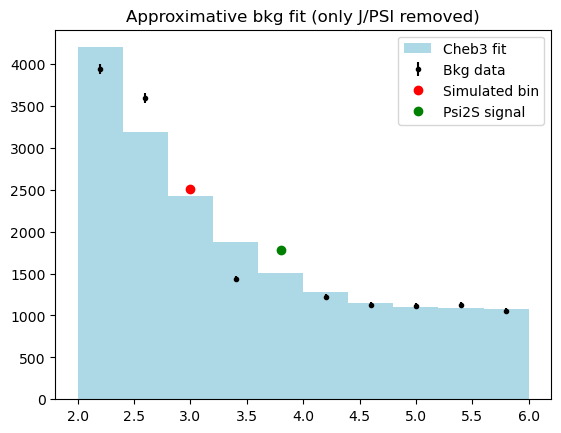

In [13]:
#cheb3 fit
Nbins = 10

fake_dataset = np.array([3]*2512) #We made up this dataset in order to simulate (approximately) the background in the removed part
                                  #We chose to make the bin 2512 high because it is the mean between the two surrounding bin counts (2512)

data_simil_bkg = np.concatenate((data_HS[(data_HS<2.8) | (data_HS>3.3)], fake_dataset ))

bNLL_HS_cheb3r = get_bNLL(data=data_simil_bkg,
                         bin_number=Nbins,
                         model=cheb3r)
initial_params = [1.15, -0.6, 0.18, -0.065] #given by the project instructions

optimization_results = minimize(bNLL_HS_cheb3r, initial_params,  method='L-BFGS-B')
optimized_params = optimization_results.x
print(optimized_params)
x = np.linspace(2,6,1000)

data_counts, bin_edges = np.histogram(data_simil_bkg, bins=Nbins, density = False)
err_data_counts = np.sqrt(data_counts)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
bin_widths = np.diff(bin_edges)

binned_result = get_binned_model(cheb3r, optimized_params, bin_edges) * len(data_simil_bkg)

plt.bar(bin_edges[:-1], binned_result, width=np.diff(bin_edges), align='edge', color = 'lightblue', label="Cheb3 fit")#, edgecolor = "black")
plt.errorbar(bin_centers, data_counts, yerr = err_data_counts, fmt = ".", linestyle = "None", color='black', label='Bkg data')
plt.errorbar(bin_centers[2], data_counts[2], fmt = "o", color = "red", label = "Simulated bin")
plt.errorbar(bin_centers[4], data_counts[4], fmt = "o", color = "green", label = "Psi2S signal")
plt.title("Approximative bkg fit (only J/PSI removed)")
plt.legend()
plt.show()

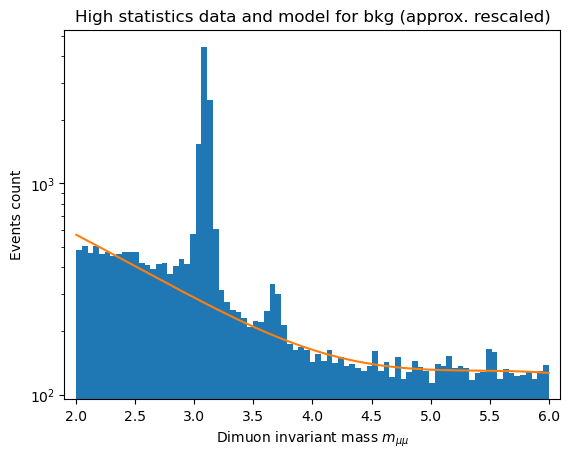

In [14]:
x = np.linspace(2,6, 1000)
y = cheb3r(x, optimized_params)
#plt.plot(x,y)
plt.figure()
plt.yscale('log')
plt.hist(data_HS, density=False, bins=bin_num)
plt.title('High statistics data and model for bkg (approx. rescaled)')
plt.xlabel('Dimuon invariant mass $m_{\\mu\\mu}$') # Use double slash for latex command
plt.ylabel('Events count')
plt.xlim((1.9,6.1))
ylim = plt.ylim()
plt.plot(x,y*900)